# Spam SMS Detection

## 1. Import Libraries

In [1]:
import re
import string
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 180)

## 2. Locate and Load Dataset


In [2]:
NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = (NOTEBOOK_DIR / ".." / "datasets").resolve()

print("Current notebook directory:", NOTEBOOK_DIR)
print("Expected dataset directory:", DATASET_DIR)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_DIR}\n"
        "Create the folder and place spam.csv inside it."
    )

csv_files = sorted(DATASET_DIR.glob("*.csv"))
print("CSV files found:", [file.name for file in csv_files])

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATASET_DIR}")

Current notebook directory: c:\Users\bhard\CODSOFT\Spam Sms Detection\code file
Expected dataset directory: C:\Users\bhard\CODSOFT\Spam Sms Detection\datasets
CSV files found: ['spam.csv']


In [3]:
preferred_file = DATASET_DIR / "spam.csv"

if preferred_file.exists():
    data_path = preferred_file
else:
    data_path = csv_files[0]
    print(f"spam.csv not found. Loading {data_path.name} instead.")

# This dataset is commonly encoded as latin-1 because some SMS messages contain special characters.
df_raw = pd.read_csv(data_path, encoding="latin-1")

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())

Raw dataset shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN


## 3. Clean Column Names and Basic Audit

In [4]:
# Keep only the useful columns from the original Kaggle file.
if {"v1", "v2"}.issubset(df_raw.columns):
    df = df_raw[["v1", "v2"]].copy()
    df.columns = ["label", "message"]
else:
    # Fallback for renamed processed datasets.
    possible_label_cols = [col for col in df_raw.columns if col.lower() in ["label", "target", "class", "spam"]]
    possible_text_cols = [col for col in df_raw.columns if col.lower() in ["message", "text", "sms", "v2"]]
    
    if not possible_label_cols or not possible_text_cols:
        raise ValueError("Could not find label/message columns. Expected v1 and v2 in spam.csv.")
    
    df = df_raw[[possible_label_cols[0], possible_text_cols[0]]].copy()
    df.columns = ["label", "message"]

df = df.dropna(subset=["label", "message"]).drop_duplicates().reset_index(drop=True)

print("Clean dataset shape:", df.shape)
print("Labels:", df["label"].unique())
display(df.head())

Clean dataset shape: (5169, 2)
Labels: ['ham' 'spam']


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


Missing values:


,missing_count
label,0
message,0



Duplicate rows after cleaning: 0


,count
label,
ham,4516
spam,653


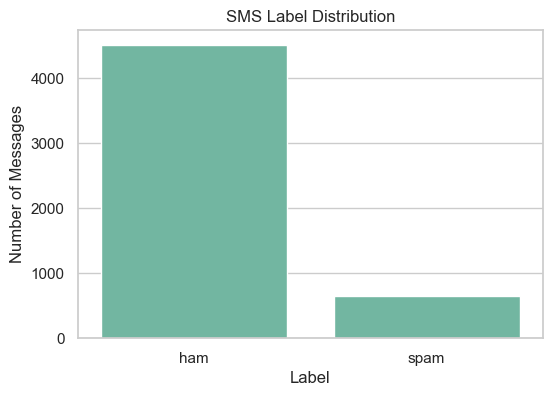

In [5]:
print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

label_counts = df["label"].value_counts()
display(label_counts.to_frame("count"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", order=label_counts.index)
plt.title("SMS Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Messages")
plt.show()

## 4. Exploratory Text Analysis

In [6]:
df["message_length"] = df["message"].astype(str).str.len()
df["word_count"] = df["message"].astype(str).str.split().str.len()
df["has_currency_symbol"] = df["message"].astype(str).str.contains(r"[$£€]", regex=True).astype(int)
df["has_number"] = df["message"].astype(str).str.contains(r"\d", regex=True).astype(int)

display(df.groupby("label")[["message_length", "word_count", "has_currency_symbol", "has_number"]].mean())

,message_length,word_count,has_currency_symbol,has_number
label,,,,
ham,70.459256,14.134632,0.003986,0.156554
spam,137.891271,23.681470,0.332312,0.940276


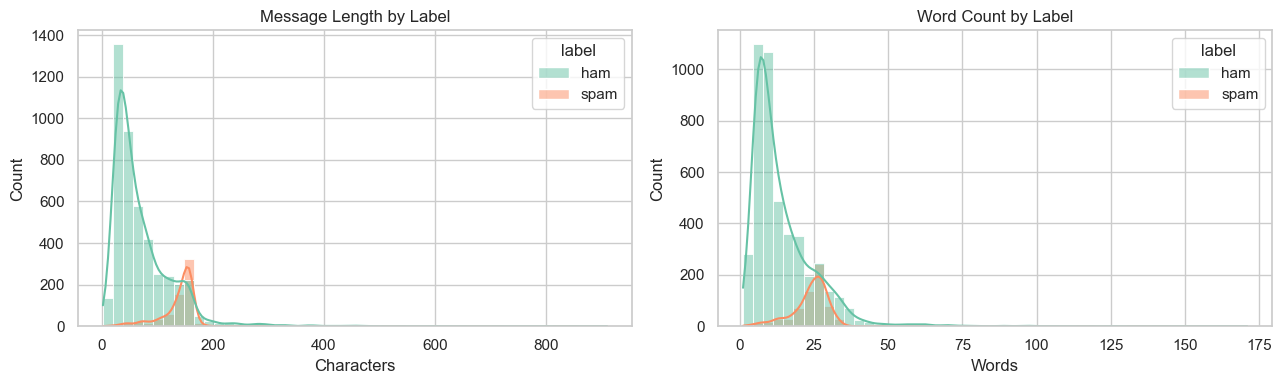

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x="message_length", hue="label", bins=50, kde=True, ax=axes[0], common_norm=False)
axes[0].set_title("Message Length by Label")
axes[0].set_xlabel("Characters")

sns.histplot(data=df, x="word_count", hue="label", bins=50, kde=True, ax=axes[1], common_norm=False)
axes[1].set_title("Word Count by Label")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

## 5. Text Cleaning and Label Encoding

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"\d+", " number ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_message"] = df["message"].apply(clean_text)
df["target"] = df["label"].map({"ham": 0, "spam": 1})

if df["target"].isna().any():
    raise ValueError("Labels must be 'ham' and 'spam' for this notebook.")

display(df[["label", "target", "message", "clean_message"]].head())

,label,target,message,clean_message
0,ham,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
1,ham,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,free entry in number a wkly comp to win fa cup final tkts number st may number text fa to number to receive entry questionstd txt ratetcs apply number over number s
3,ham,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,0,"Nah I don't think he goes to usf, he lives around here though",nah i dont think he goes to usf he lives around here though


## 6. Train/Test Split

In [9]:
X = df["clean_message"]
y = df["target"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))
print("Training class ratio:")
print(y_train.value_counts(normalize=True).rename({0: "ham", 1: "spam"}))

Training messages: 4135
Testing messages: 1034
Training class ratio:
target
ham     0.873761
spam    0.126239
Name: proportion, dtype: float64


## 7. Train Classification Models


In [10]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42,
    ),
}

trained_models = {}
evaluation_rows = []

for name, model in models.items():
    print(f"Training {name}...")
    
    pipeline = Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    ngram_range=(1, 2),
                    min_df=1,
                    max_df=0.95,
                    max_features=20_000,
                    sublinear_tf=True,
                ),
            ),
            ("model", model),
        ]
    )
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    trained_models[name] = pipeline
    evaluation_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        }
    )

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("f1", ascending=False)
display(evaluation_df)

Training Multinomial Naive Bayes...
Training Logistic Regression...
Training Linear SVM...


,model,accuracy,precision,recall,f1
2,Linear SVM,0.981625,0.930769,0.923664,0.927203
1,Logistic Regression,0.961315,0.786164,0.954198,0.862069
0,Multinomial Naive Bayes,0.962282,1.000000,0.702290,0.825112


## 8. Evaluate Best Model

Best model based on F1-score: Linear SVM
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.93      0.92      0.93       131

    accuracy                           0.98      1034
   macro avg       0.96      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034

ROC-AUC: 0.9940359953674351
PR-AUC: 0.9600805500720009


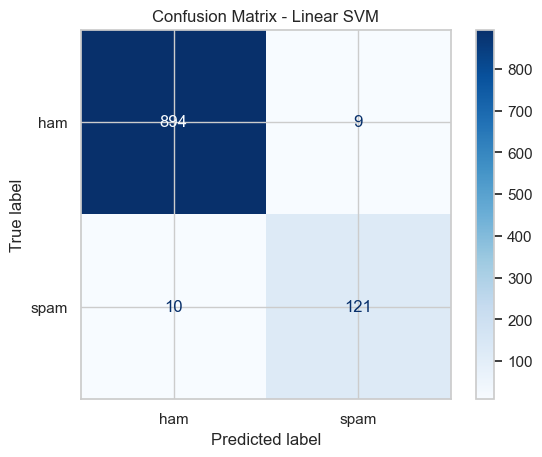

In [11]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X)
        return (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    return model.predict(X)


best_model_name = evaluation_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model based on F1-score:", best_model_name)

y_pred_best = best_model.predict(X_test)
y_score_best = get_scores(best_model, X_test)

print(classification_report(y_test, y_pred_best, target_names=["ham", "spam"], zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_score_best))
print("PR-AUC:", average_precision_score(y_test, y_score_best))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

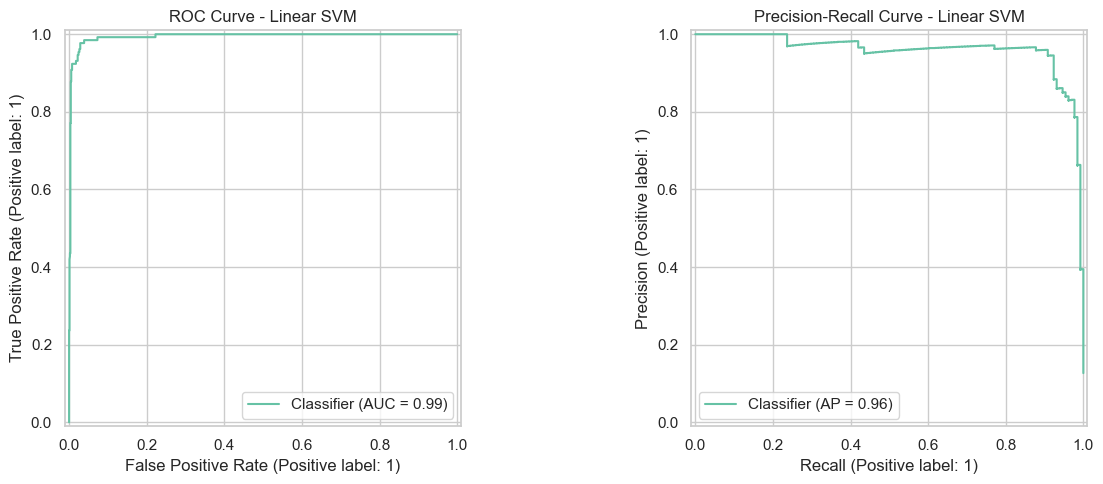

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, y_score_best, ax=axes[0])
axes[0].set_title(f"ROC Curve - {best_model_name}")

PrecisionRecallDisplay.from_predictions(y_test, y_score_best, ax=axes[1])
axes[1].set_title(f"Precision-Recall Curve - {best_model_name}")

plt.tight_layout()
plt.show()

## 9. Inspect Important Words

In [13]:
tfidf = best_model.named_steps["tfidf"]
estimator = best_model.named_steps["model"]
feature_names = np.array(tfidf.get_feature_names_out())

if hasattr(estimator, "coef_"):
    coefficients = estimator.coef_[0]
    top_spam_idx = np.argsort(coefficients)[-20:][::-1]
    top_ham_idx = np.argsort(coefficients)[:20]
    
    important_words_df = pd.DataFrame(
        {
            "top_spam_words": feature_names[top_spam_idx],
            "spam_weight": coefficients[top_spam_idx],
            "top_ham_words": feature_names[top_ham_idx],
            "ham_weight": coefficients[top_ham_idx],
        }
    )
    display(important_words_df)
else:
    print("Feature coefficients are not available for this model type.")

,top_spam_words,spam_weight,top_ham_words,ham_weight
0,url,3.027763,ltgt,-0.835435
1,number number,2.901685,ill,-0.773133
2,number,1.971863,ok,-0.654666
3,mobile,1.896049,home,-0.603659
4,text,1.777109,said,-0.591881
5,reply,1.698963,hey,-0.556386
6,txt,1.629786,work,-0.552733
7,service,1.497998,text youre,-0.549971
8,claim,1.353012,say,-0.548546
9,ringtone,1.232943,road,-0.543384


## 10. Test Custom SMS Messages

In [14]:
def predict_sms(message):
    cleaned_message = clean_text(message)
    prediction = best_model.predict([cleaned_message])[0]
    score = get_scores(best_model, [cleaned_message])[0]
    label = "spam" if prediction == 1 else "ham"
    return label, float(score)


examples = [
    "Congratulations! You have won a free ticket. Call now to claim your prize.",
    "Hey, are we still meeting for lunch today?",
    "URGENT! Your account has been selected for a cash reward. Reply WIN now.",
]

for message in examples:
    label, score = predict_sms(message)
    print("Message:", message)
    print("Prediction:", label, "| spam score:", round(score, 4))
    print("-")

Message: Congratulations! You have won a free ticket. Call now to claim your prize.
Prediction: spam | spam score: nan
-
Message: Hey, are we still meeting for lunch today?
Prediction: ham | spam score: nan
-
Message: URGENT! Your account has been selected for a cash reward. Reply WIN now.
Prediction: spam | spam score: nan
-


## 11. Save Model

In [15]:
MODEL_DIR = (NOTEBOOK_DIR / "models").resolve()
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "spam_sms_classifier.joblib"
joblib.dump(best_model, model_path)

print("Saved model to:", model_path)

Saved model to: C:\Users\bhard\CODSOFT\Spam Sms Detection\code file\models\spam_sms_classifier.joblib


## Conclusion

This notebook completed a full SMS spam detection workflow:

- Loaded the official Codsoft/Kaggle SMS spam dataset.
- Cleaned the original `v1` and `v2` columns into label and message fields.
- Explored class balance and message-length patterns.
- Preprocessed message text.
- Trained TF-IDF based Naive Bayes, Logistic Regression, and Linear SVM classifiers.
- Evaluated models using accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, confusion matrix, and classification report.
- Tested custom SMS messages and saved the trained classifier.
